In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AirPassengers (1).csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
#Change month format
df['Month'] = pd.to_datetime(df['Month'], errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [7]:
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [8]:
df = df.set_index('Month')
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [9]:
df = df.rename(columns = {'#Passengers':'Passengers'})
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


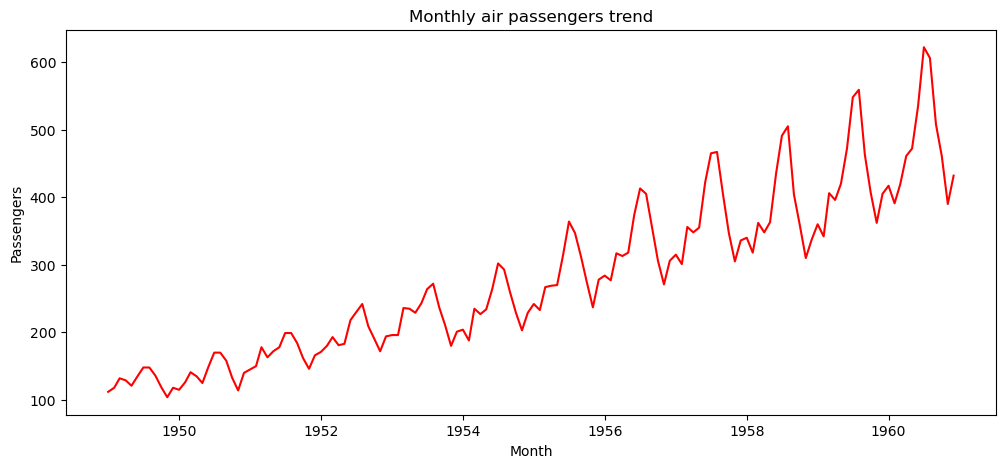

In [10]:
plt.figure(figsize=(12, 5))
sns.lineplot(x= df.index,y= df['Passengers'], color = 'red')
plt.title('Monthly air passengers trend')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.show()

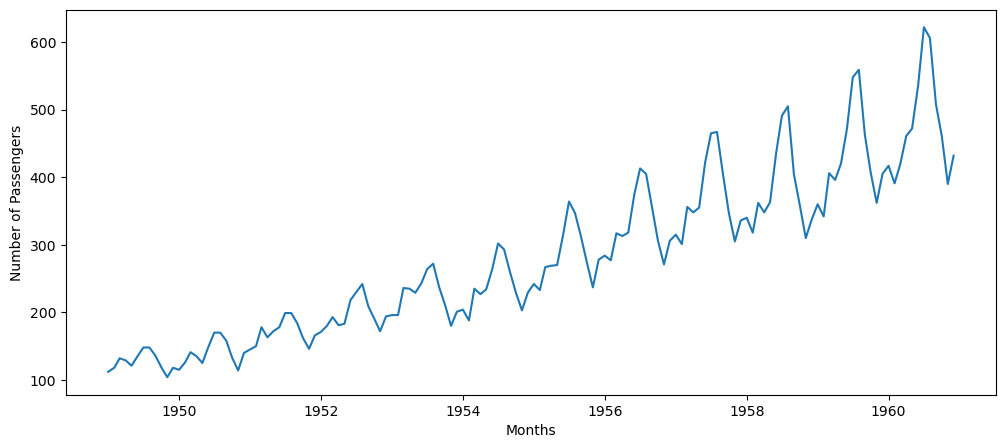

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df.index,df['Passengers'])
plt.xlabel('Months')
plt.ylabel('Number of Passengers')
plt.show()

In [12]:
# Seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.datasets import co2

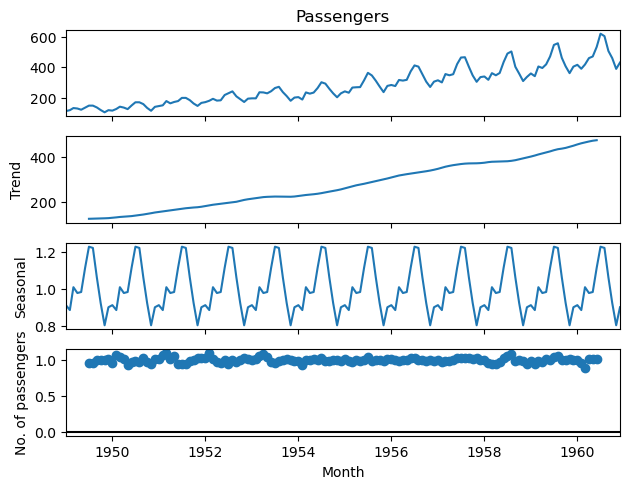

In [13]:
result_air = seasonal_decompose(df['Passengers'], model="multiplicative", period=12)
result_air.plot()
plt.xlabel('Month')
plt.ylabel('No. of passengers')
plt.show()

In [14]:
#Check for stationarity - Augmented DIckey Fuller test
from statsmodels.tsa.stattools import adfuller

# Run the Augmented Dickey-Fuller test
result = adfuller(df)
print(result)
# Print key output metrics
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

(np.float64(0.8153688792060472), np.float64(0.991880243437641), 13, 130, {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}, np.float64(996.6929308390189))
ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641
Critical Values:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598


In [15]:
if result[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

Not stationary


# If the seasonality is additive then differencing, if it is multiplicative then log transformation

In [16]:
# Log transformation and perform adf over the data
import numpy as np

# Apply log transformation to the 'Passengers' column
df_log = np.log(df)

# Check the first few rows
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [17]:
result = adfuller(df_log.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value      : {result[1]:.4f}")

ADF Statistic: -1.7170
p-value      : 0.4224


In [18]:
if result[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

Not stationary


In [19]:
#First order difference
d1 = df_log.diff().dropna()
r = adfuller(d1)
print(f"ADF Statistic: {r[0]}")
print(f"p-value      : {r[1]}")

ADF Statistic: -2.717130598388141
p-value      : 0.07112054815085739


In [20]:
if r[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

Not stationary


In [21]:
d2 = d1.diff().dropna()
r = adfuller(d2)
print(f"ADF Statistic: {r[0]}")
print(f"p-value      : {r[1]}")

if r[1] <= 0.05:
    print("The series is stationary")
else:
    print("Not stationary")

ADF Statistic: -8.196629132182162
p-value      : 7.419304549379596e-13
The series is stationary


In [23]:
#ARIMA p = d= q= 
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

train,test=train_test_split(
    df_log,
    test_size=0.2,
    shuffle=False
)

p_val=range(1,8)
q_val=range(1,8)

combi=list(itertools.product(p_val,q_val))

res=[]
for p,q in combi:
    model = ARIMA(train,order=(p,2,q))
    m_f=model.fit()

    p_log=m_f.predict(
      start=len(train),
      end=len(train)+len(test)-1
    )
    predicted = np.exp(p_log)
    actual = np.exp(test['Passengers'])

    #rmse - Root mean-squared error
    rmse = root_mean_squared_error(actual, predicted)
    res.append({'p': p, 'd':2,'q': q, 'RMSE': rmse})

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequenc

In [24]:
results_df = pd.DataFrame(res, columns = ['p','d','q','RMSE'])
#results_df['d']= 2
results_df.sort_values(by='RMSE', ascending=True, inplace=True)
results_df.head()

,p,d,q,RMSE
38,6,2,4,77.335862
24,4,2,4,78.316958
20,3,2,7,79.263589
4,1,2,5,79.310677
13,2,2,7,79.641895


In [25]:
#SARIMA - Seasonal ARIMA - adding seasonality to improve the prediction
from statsmodels.tsa.statespace.sarimax import SARIMAX
train,test=train_test_split(
    df_log,
    test_size=0.2,
    shuffle=False
)

p_val = range(0, 3)
q_val = range(0, 3)
P_val = range(0, 2)
Q_val = range(0, 2)

combi=list(itertools.product(p_val,q_val,P_val,Q_val))

res=[]
for p,q,P,Q in combi:
    model = SARIMAX(train,order=(p,1,q),seasonal_order = (P,1,Q,12))
    m_f=model.fit()

    p_log=m_f.predict(
      start=len(train),
      end=len(train)+len(test)-1
    )
    predicted = np.exp(p_log)
    actual = np.exp(test['Passengers'])

    #rmse - Root mean-squared error
    rmse = root_mean_squared_error(actual, predicted)
    res.append({'order': (p,1,q), 'seasonal_order':(P,1,Q,12),'RMSE': rmse,'AIC':m_f.aic})

#AIC -AIC (Akaike Information Criterion) measures how well a model fits your data relative to its complexity.
#It helps you choose the best model parameters ($p, d, q$) without relying on a test set split.
#Lower is better: A lower AIC score means the model captures the underlying pattern well without overfitting.
#In-sample metric: Unlike RMSE (which requires a test split), AIC evaluates model quality directly on the training data by penalizing
#unnecessary parameters.

C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequenc

In [26]:
sar_results_df = pd.DataFrame(res, columns = ['order','seasonal_order','RMSE','AIC'])
#results_df['d']= 2
sar_results_df.sort_values(by='RMSE', ascending=True, inplace=True)
sar_results_df.head()

,order,seasonal_order,RMSE,AIC
13,"(1, 1, 0)","(0, 1, 1, 12)",14.926442,-371.865316
17,"(1, 1, 1)","(0, 1, 1, 12)",14.928679,-369.862023
25,"(2, 1, 0)","(0, 1, 1, 12)",14.940398,-369.867192
33,"(2, 1, 2)","(0, 1, 1, 12)",14.973988,-368.728597
15,"(1, 1, 0)","(1, 1, 1, 12)",14.996313,-370.042458
